# CMSC6950 Homework #5

Isaac Adoboe - ieadoboe@mun.ca

### Question 1

### Question 2

### Problem (a)

In [1]:
import numpy as np
npzfile = np.load("iterations.npz")

In [2]:
npzfile.files

['iteration_counts']

In [3]:
iteration_counts = npzfile['iteration_counts']
print(iteration_counts)

[ 19  12   9   7  21  13   9 100   7  23  13   9   7  26  13   8   7  18
  11   9   8  18  11  10  19  12  11  20  12  13  12  18  10   8   7  16
  10   8   7  16  10   9   7  17  10   9   8  18  10   8   7  16  10   8
   8  16  10   9   8  16  10   9   9  18  10   8   7  17  10   8   7  15
  10   9   7  16  10   8   7  18  10   8   7  37  16  10   9   7  15  10
   9   7  15  10   9   9  24 100 100  16  27 100  30  15  10  24  16  12
  11  24  16  14  12  24  17  15  13  25  18  15  14  19  12  10   8  21
 100 100  81  58  55  60  70  60  89  82  50  46  51  49  63  85  60  63
 100  65  78 100  82 100]


In [4]:
len(iteration_counts)

150

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from common import MPL_CONFIG

mpl.rcParams.update(MPL_CONFIG)

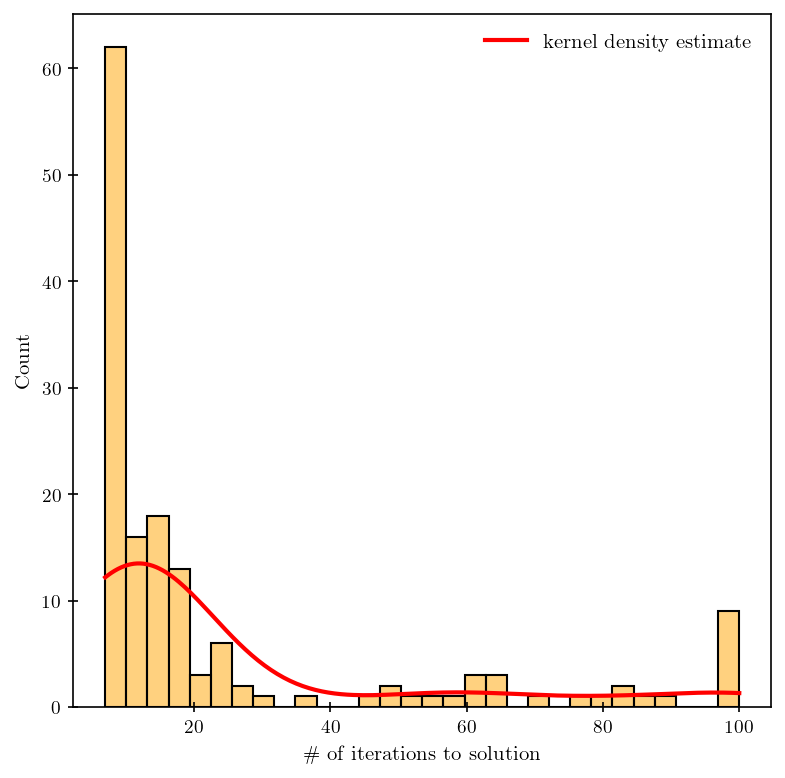

In [6]:
plt.figure(figsize=(6, 6))
ax = sns.histplot(iteration_counts, bins=30, color='orange', kde=True)
ax.lines[0].set_color('red')
plt.xlabel("\\# of iterations to solution")
plt.legend(["kernel density estimate"])
plt.savefig("iteration_counts_hist_kde.pdf")

### Problem (b)

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from common import MPL_CONFIG

mpl.rcParams.update(MPL_CONFIG)

In [8]:
import numpy as np
npzfile = np.load("heights.npz")
npzfile.files

['X', 'Y', 'height_25', 'height_50', 'height_75', 'height_100']

In [9]:
X = npzfile['X']
Y = npzfile['Y']
height_25 = npzfile['height_25']
height_50 = npzfile['height_50']
height_75 = npzfile['height_75']
height_100 = npzfile['height_100']

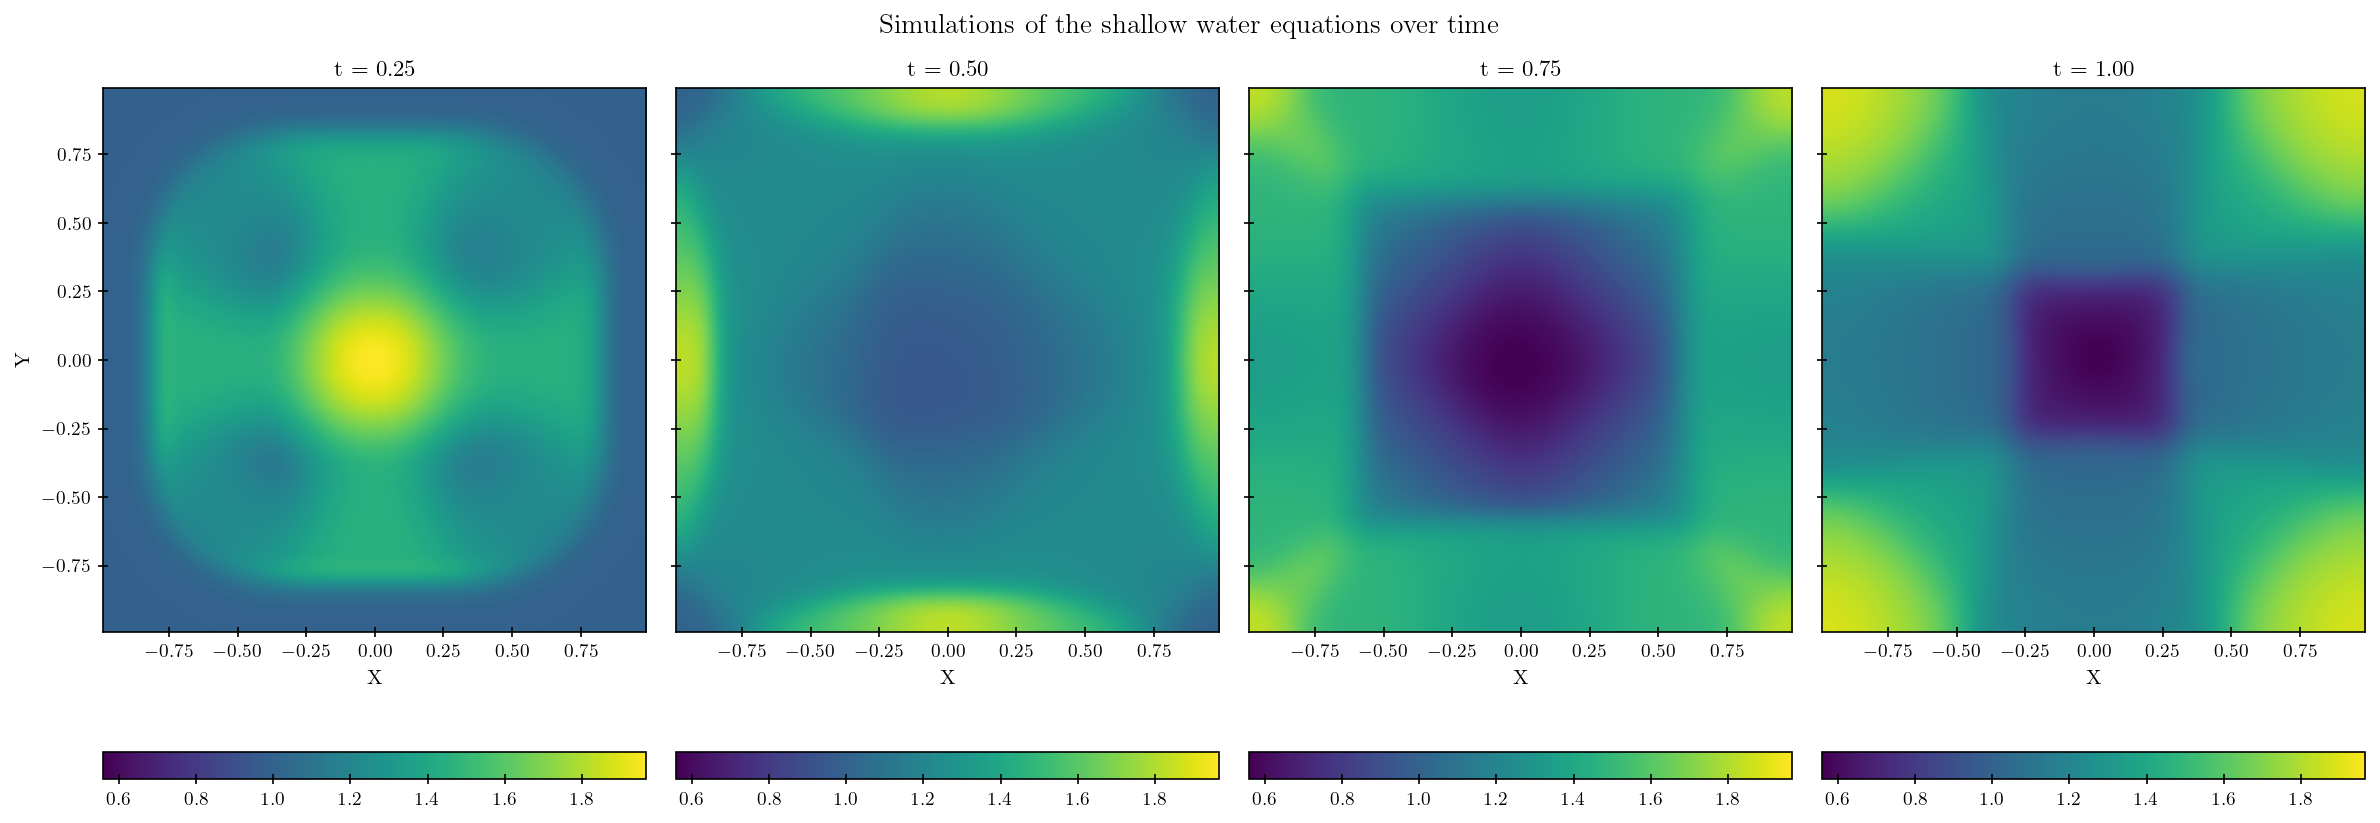

In [10]:
params = {'figure.figsize': [16, 6]}
mpl.rcParams.update(params)

# Data
times = [0.25, 0.50, 0.75, 1.00]
heights = [height_25, height_50, height_75, height_100]

vmin = min([h.min() for h in heights])
vmax = max([h.max() for h in heights])

kwargs = {'origin': 'lower',
          'cmap': 'viridis',
          'vmin': vmin,
          'vmax': vmax,
          'extent': [X.min(), X.max(), Y.min(), Y.max()],
          }


fig, ax = plt.subplots(nrows=1, ncols=4, sharey=True, sharex=True)
ax = ax.flatten()

# Plots
# Plot for 0.25
im = ax[0].imshow(
    height_25, interpolation='bilinear', **kwargs)
ax[0].set_title("t = 0.25")
fig.colorbar(im, ax=ax[0], orientation='horizontal')

# Plot for 0.5
im = ax[1].imshow(
    height_50, interpolation='bilinear', **kwargs)
ax[1].set_title("t = 0.50")
fig.colorbar(im, ax=ax[1], orientation='horizontal')

# Plot for 0.75
im = ax[2].imshow(
    height_75, interpolation='bilinear', **kwargs)
ax[2].set_title("t = 0.75")
fig.colorbar(im, ax=ax[2], orientation='horizontal')

# Plot for 1.0
im = ax[3].imshow(
    height_100, interpolation='bilinear', **kwargs)
ax[3].set_title("t = 1.00")
fig.colorbar(im, ax=ax[3], orientation='horizontal')

fig.suptitle('Simulations of the shallow water equations over time')

# Axis labels
ax[0].set_ylabel('Y')
ax[0].set_xlabel('X')
ax[1].set_xlabel('X')
ax[2].set_xlabel('X')
ax[3].set_xlabel('X')

plt.tight_layout()
plt.savefig('heatmap_1x4_heights_data.pdf')
plt.show()

### Problem (c)

Plot this data in a suitable set of line graphs, demonstrating convergence of the reconnection rate with resolution for each Reynolds number.

- 3 different Reynolds numbers (5000, 10000, 20000)
- 4 different grid resolutions (denoted by nref4, nref5, nref6, and nref7)

This gives a 3 x 4 combination = 12 Reconnection Rates 

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from common import MPL_CONFIG

mpl.rcParams.update(MPL_CONFIG)

In [12]:
import numpy as np
npzfile = np.load("RR_data.npz")
npzfile.files

['times_nref4',
 'times_nref5',
 'times_nref6',
 'times_nref7',
 'RR5000_nref4',
 'RR5000_nref5',
 'RR5000_nref6',
 'RR5000_nref7',
 'RR10000_nref4',
 'RR10000_nref5',
 'RR10000_nref6',
 'RR10000_nref7',
 'RR20000_nref4',
 'RR20000_nref5',
 'RR20000_nref6',
 'RR20000_nref7']

In [13]:
# Data
# times
times_nref4 = npzfile['times_nref4']
times_nref5 = npzfile['times_nref5']
times_nref6 = npzfile['times_nref6']
times_nref7 = npzfile['times_nref7']

# Reynold number - 5000
RR5000_nref4 = npzfile['RR5000_nref4']
RR5000_nref5 = npzfile['RR5000_nref5']
RR5000_nref6 = npzfile['RR5000_nref6']
RR5000_nref7 = npzfile['RR5000_nref7']

# Reynold number - 10000
RR10000_nref4 = npzfile['RR10000_nref4']
RR10000_nref5 = npzfile['RR10000_nref5']
RR10000_nref6 = npzfile['RR10000_nref6']
RR10000_nref7 = npzfile['RR10000_nref7']

# Reynold number - 20000
RR20000_nref4 = npzfile['RR20000_nref4']
RR20000_nref5 = npzfile['RR20000_nref5']
RR20000_nref6 = npzfile['RR20000_nref6']
RR20000_nref7 = npzfile['RR20000_nref7']

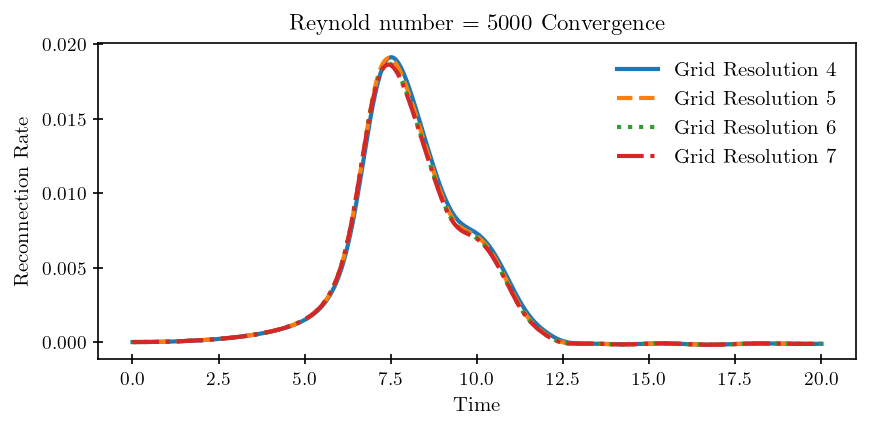

In [14]:
params = {'figure.figsize': [6, 3]}
mpl.rcParams.update(params)

plt.figure()
ax = plt.gca()

kwargs = {'lw': 2}

ax.plot(times_nref4, RR5000_nref4,  label='Grid Resolution 4',
        **kwargs, linestyle='solid')
ax.plot(times_nref5, RR5000_nref5,  label='Grid Resolution 5',
        **kwargs, linestyle='dashed')
ax.plot(times_nref6, RR5000_nref6,  label='Grid Resolution 6',
        **kwargs, linestyle='dotted')
ax.plot(times_nref7, RR5000_nref7,  label='Grid Resolution 7',
        **kwargs, linestyle='dashdot')

ax.set_xlabel('Time')
ax.set_ylabel('Reconnection Rate')
ax.set_title('Reynold number = 5000 Convergence')
ax.legend()

plt.tight_layout()

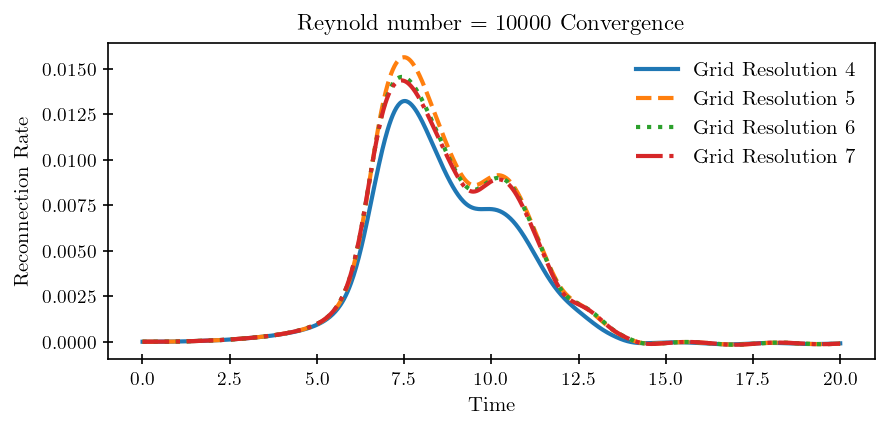

In [15]:
plt.figure()
ax = plt.gca()

kwargs = {'lw': 2}

ax.plot(times_nref4, RR10000_nref4,  label='Grid Resolution 4',
        **kwargs, linestyle='solid')
ax.plot(times_nref5, RR10000_nref5,  label='Grid Resolution 5',
        **kwargs, linestyle='dashed')
ax.plot(times_nref6, RR10000_nref6,  label='Grid Resolution 6',
        **kwargs, linestyle='dotted')
ax.plot(times_nref7, RR10000_nref7,  label='Grid Resolution 7',
        **kwargs, linestyle='dashdot')

ax.set_xlabel('Time')
ax.set_ylabel('Reconnection Rate')
ax.set_title('Reynold number = 10000 Convergence')
ax.legend()

plt.tight_layout()

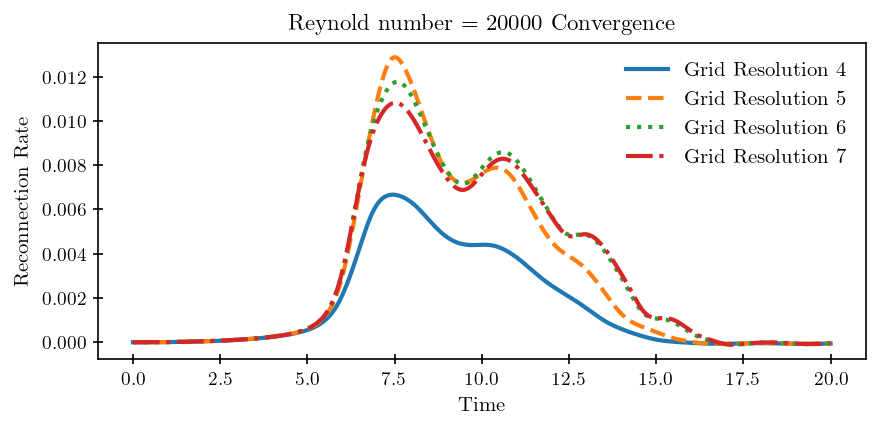

In [16]:
plt.figure()
ax = plt.gca()

kwargs = {'lw': 2}

ax.plot(times_nref4, RR20000_nref4,  label='Grid Resolution 4',
        **kwargs, linestyle='solid')
ax.plot(times_nref5, RR20000_nref5,  label='Grid Resolution 5',
        **kwargs, linestyle='dashed')
ax.plot(times_nref6, RR20000_nref6,  label='Grid Resolution 6',
        **kwargs, linestyle='dotted')
ax.plot(times_nref7, RR20000_nref7,  label='Grid Resolution 7',
        **kwargs, linestyle='dashdot')

ax.set_xlabel('Time')
ax.set_ylabel('Reconnection Rate')
ax.set_title('Reynold number = 20000 Convergence')
ax.legend()

plt.tight_layout()